In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) #low-pass filter
HPF = np.array([-1/np.sqrt(2), (1/np.sqrt(2))]) #high-pass filter

In [3]:
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((0, 0), (pad_width, pad_width)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2

    padd = np.pad(
        image,
        ((0,0),(pad_width,pad_width)),
        mode='constant'
    )

    conv = np.zeros(image.shape)

    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i,j] += (
                    padd[i,j+x]
                    * kernel[ukuran_kernel-1-x]
                )

    return conv

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((pad_width, pad_width), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv

def downsampling_h(image):
    downsampled = np.zeros((image.shape[0], image.shape[1] // 2))
    for i in range(len(downsampled)):
        indeks = 0
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape)
    return (image - min_val) / (max_val - min_val) * 255

def wavelet(image):
    # LL (Approximation)
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)
    approximation = normalisasi(approximation)

    # LH (Horizontal Detail)
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)
    horizontal = normalisasi(horizontal)

    # HL (Vertical Detail)
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)
    vertikal = normalisasi(vertikal)

    # HH (Diagonal Detail)
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)
    diagonal = normalisasi(diagonal)

    return (approximation, horizontal, vertikal, diagonal)

In [4]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)): 
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

In [5]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

# hasil = rekonstruksi(approximation, horizontal, vertikal, diagonal, LPF, HPF)

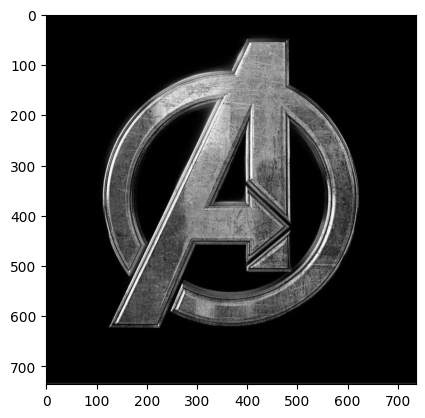

In [6]:
doomsday = cv.imread('doomsday.jpg')
doomsdayGray = cv.cvtColor(doomsday, cv.COLOR_BGR2GRAY)
plt.imshow(doomsdayGray, cmap='gray')

In [7]:
ll_dom, lh_dom, hl_dom, hh_dom = wavelet(doomsdayGray)

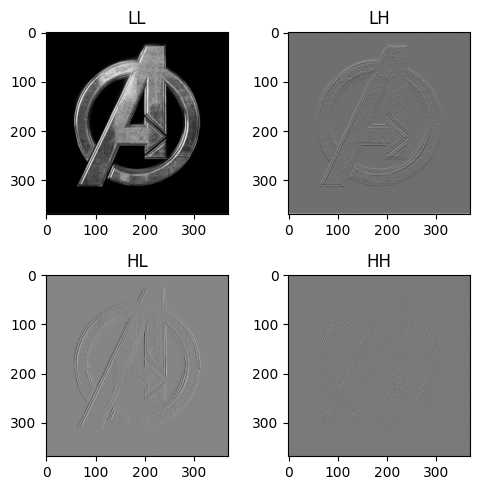

In [8]:
plt.figure(figsize=(5,5))

plt.subplot(2,2,1)
plt.imshow(ll_dom, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(lh_dom, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(hl_dom, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(hh_dom, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

In [9]:
def Thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i,j] >= batas:
                canvas[i,j] = 255
            elif img[i,j] <= batas:
                canvas[i,j] = 0
    return canvas

In [10]:
HL_tr = Thresholding(hl_dom, 150)
LH_tr = Thresholding(lh_dom, 135)
HH_tr = Thresholding(hh_dom, 140)

pada soal disuruh menggunakan treshold = 150, tapi yang sesuai dengan gambar soalnya hanya bagian HL, untuk LH dan HH nya lebih mirip jika menggunakan LH tresholdnya 135 dan HH tresholdnya 140

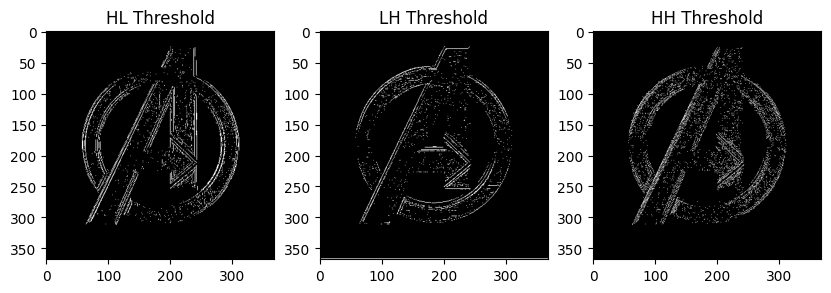

In [11]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(HL_tr, cmap='gray')
plt.title('HL Threshold')

plt.subplot(1,3,2)
plt.imshow(LH_tr, cmap='gray')
plt.title('LH Threshold')

plt.subplot(1,3,3)
plt.imshow(HH_tr, cmap='gray')
plt.title('HH Threshold')

plt.show()

In [12]:
def Dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil


def Erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil

def closing(image, kernel):
    return Erosi(Dilasi(image, kernel), kernel)

In [13]:
kernel5 = np.array ([[0, 0, 1, 0, 0],
                     [0, 1, 1, 1, 0],
                     [1, 1, 1, 1, 1],
                     [0, 1, 1, 1, 0],
                     [0, 0, 1, 0, 0]])

In [14]:
HL_cl = closing(HL_tr, kernel5)
LH_cl = closing(LH_tr, kernel5)
HH_cl = closing(HH_tr, kernel5)

closing dilakukukan pada gambar hasil threshold agar dapat memperlihatkan dengan lebih jelas objek yang terdapat pada gambar

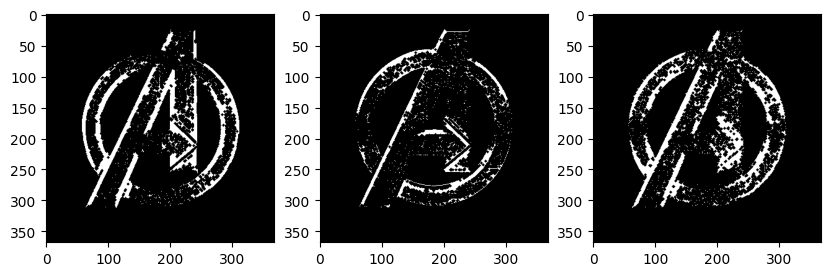

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(HL_cl, cmap='gray')

plt.subplot(1,3,2)
plt.imshow(LH_cl, cmap='gray')

plt.subplot(1,3,3)
plt.imshow(HH_cl, cmap='gray')

plt.show()

In [16]:
hasil_a = rekonstruksi(ll_dom, hl_dom, lh_dom, hh_dom, LPF, HPF)
LL0 = np.zeros_like(ll_dom)
hasil_b = rekonstruksi(LL0, lh_dom, hl_dom, hh_dom, LPF, HPF)
hasil_c = rekonstruksi(LL0, LH_cl, HL_cl, HH_cl, LPF, HPF)

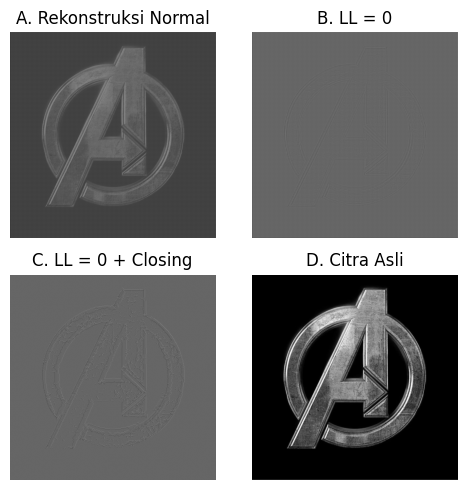

In [17]:
plt.figure(figsize=(5,5))

# a
plt.subplot(2,2,1)
plt.imshow(hasil_a, cmap='gray')
plt.title('A. Rekonstruksi Normal')
plt.axis('off')

# b
plt.subplot(2,2,2)
plt.imshow(hasil_b, cmap='gray')
plt.title('B. LL = 0')
plt.axis('off')

# c
plt.subplot(2,2,3)
plt.imshow(hasil_c, cmap='gray')
plt.title('C. LL = 0 + Closing')
plt.axis('off')

# d
plt.subplot(2,2,4)
plt.imshow(doomsdayGray, cmap='gray')
plt.title('D. Citra Asli')
plt.axis('off')

plt.tight_layout()
plt.show()

* hasil_a = rekonstruksi(...): Rekonstruksi penuh menggunakan semua subband asli (LL, LH, HL, HH).
* LL0 = np.zeros_like(ll_dom): Membuat matriks nol berukuran sama dengan subband pendekatan (LL).
* hasil_b = rekonstruksi(LL0, ...): Rekonstruksi dengan membuang informasi frekuensi rendah (LL = 0).
* hasil_c = rekonstruksi(LL0, LH_cl, ...): Rekonstruksi tanpa LL dan subband detailnya telah diberi operasi morfologi Closing.

hasil_a
  * **Proses**: Melakukan rekonstruksi citra secara penuh.
  * **Komponen**: Menggunakan seluruh subband asli asli yaitu LL (pendekatan), serta LH, HL, dan HH (detail).

hasil_b
  * **Proses**: Melakukan rekonstruksi parsial pada citra.
  * **Karakteristik**: Membuang seluruh informasi frekuensi rendah dengan cara mengubah nilai subband LL menjadi nol.

hasil_c
  * **Proses**: Melakukan rekonstruksi modifikasi.
  * **Karakteristik**: Menghilangkan komponen frekuensi rendah (LL = 0) dan memproses seluruh subband detail (LH, HL, HH) menggunakan operasi morfologi **Closing** terlebih dahulu.

d itu mirip citra asli yang di gray kan...
